C:\Users\CODO\AppData\Local\Temp\ipykernel_32336\171959342.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("coolwarm")(norm(temps))


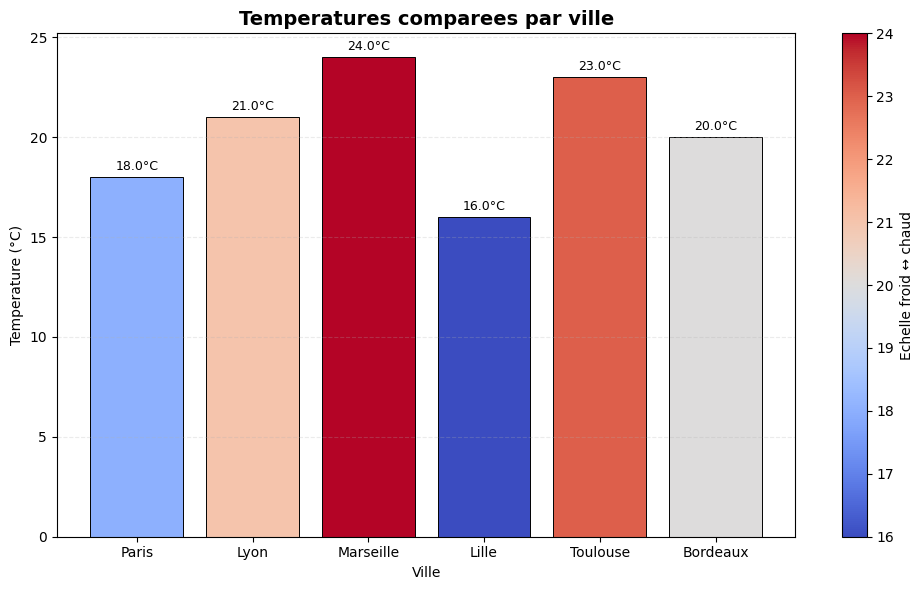

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# Donnees exemple: une ligne par ville
df = pd.DataFrame(
    {
        "ville": ["Paris", "Lyon", "Marseille", "Lille", "Toulouse", "Bordeaux"],
        "temperature": [18.0, 21.0, 24.0, 16.0, 23.0, 20.0],
        "humidite": [68, 55, 62, 74, 49, 59],
    }
)

# Graphique 1: Temperatures comparees (une barre par ville)
out_dir = Path("outputs") if Path("outputs").exists() else Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

temps = df["temperature"].to_numpy()
norm = Normalize(vmin=temps.min(), vmax=temps.max())
colors = cm.get_cmap("coolwarm")(norm(temps))

bars = ax.bar(df["ville"], temps, color=colors, edgecolor="black", linewidth=0.7)
ax.set_title("Temperatures comparees par ville", fontsize=14, weight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Ville")
ax.grid(axis="y", alpha=0.25, linestyle="--")

for bar, value in zip(bars, temps):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.1f}°C",
        ha="center",
        va="bottom",
        fontsize=9,
    )

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap="coolwarm"), ax=ax)
cbar.set_label("Echelle froid ↔ chaud")

plt.tight_layout()
plt.savefig(out_dir / "temperatures.png", dpi=160, bbox_inches="tight")
plt.show()

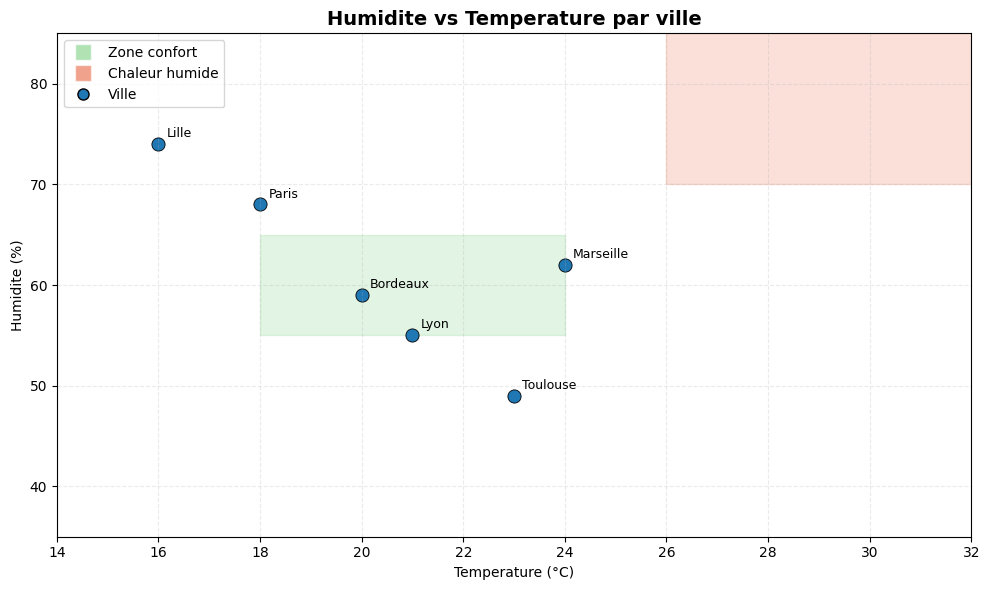

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Graphique 2: Humidite vs Temperature (confort)
if "df" not in globals():
    import pandas as pd
    df = pd.DataFrame(
        {
            "ville": ["Paris", "Lyon", "Marseille", "Lille", "Toulouse", "Bordeaux"],
            "temperature": [18.0, 21.0, 24.0, 16.0, 23.0, 20.0],
            "humidite": [68, 55, 62, 74, 49, 59],
        }
    )

out_dir = Path("outputs") if Path("outputs").exists() else Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Zone de confort (approx.): temperature 18-24, humidite 40-60
ax.axvspan(18, 24, ymin=(40/100), ymax=(60/100), color="#8FD694", alpha=0.25, label="Zone confort")

# Zone chaleur humide (approx.): temperature >= 26 et humidite >= 70
ax.axvspan(26, 40, ymin=(70/100), ymax=1.0, color="#E4572E", alpha=0.18, label="Chaleur humide")

ax.scatter(df["temperature"], df["humidite"], s=90, color="#1f77b4", edgecolor="black", linewidth=0.6)

for _, row in df.iterrows():
    ax.annotate(
        row["ville"],
        (row["temperature"], row["humidite"]),
        textcoords="offset points",
        xytext=(6, 5),
        fontsize=9,
    )

ax.set_title("Humidite vs Temperature par ville", fontsize=14, weight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Humidite (%)")
ax.set_xlim(14, 32)
ax.set_ylim(35, 85)
ax.grid(alpha=0.25, linestyle="--")

legend_elements = [
    Line2D([0], [0], marker="s", color="w", label="Zone confort", markerfacecolor="#8FD694", markersize=12, alpha=0.7),
    Line2D([0], [0], marker="s", color="w", label="Chaleur humide", markerfacecolor="#E4572E", markersize=12, alpha=0.55),
    Line2D([0], [0], marker="o", color="w", label="Ville", markerfacecolor="#1f77b4", markeredgecolor="black", markersize=8),
]
ax.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig(out_dir / "confort.png", dpi=160, bbox_inches="tight")
plt.show()